In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

# Импортируем ВСЕ способы разбиения, которые будем изучать
from sklearn.model_selection import (
    train_test_split,       # простое одиночное разбиение
    KFold,                   # K фолдов (без стратификации)
    StratifiedKFold,         # K фолдов с сохранением пропорций классов
    GroupKFold,              # K фолдов с непересекающимися группами
    TimeSeriesSplit,         # для временных рядов (без перемешивания)
    ShuffleSplit,            # случайные подвыборки
    RepeatedKFold,           # повторяющийся KFold
    LeaveOneOut,             # по одному образцу
    cross_val_score          # автоматическая кросс-валидация
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error

print("Библиотеки загружены!")

Библиотеки загружены!


In [ ]:
#   Готовим 2 датасета для экспериментов:
#   1. Отток сотрудников (классификация)
#   2. Продажи по месяцам (временной ряд, регрессия)

np.random.seed(42)

# --- Датасет 1: Отток сотрудников (churn)
N_emp = 500  # 500 сотрудников
departments = np.random.choice(['IT', 'HR', 'Sales', 'Finance'], N_emp)
# Создаём признаки: стаж, зарплата, уровень удовлетворённости
tenure = np.random.randint(1, 20, N_emp)                    # стаж от 1 до 19 лет
salary = np.random.normal(50000, 20000, N_emp).clip(15000)  # зарплата
satisfaction = np.random.uniform(0, 10, N_emp)              # удовлетворённость (0-10)

# Отток зависит от признаков + шум (12% уходят)
churn_prob = 0.12 * (1 + (tenure < 3).astype(int) + (satisfaction < 3).astype(int))
churn = (np.random.random(N_emp) < churn_prob).astype(int)

X_emp = np.column_stack([tenure, salary, satisfaction])     # форма (500, 3)
y_emp = churn                                               # 0 — остался, 1 — ушёл
emp_ids = np.repeat(np.arange(N_emp // 2), 2)[:N_emp]       # группы: у каждого сотрудника ~2 записи

# --- Датасет 2: Продажи по месяцам (временной ряд) ---
months = np.arange(1, 61)                                    # 60 месяцев (5 лет)
trend = months * 100                                          # линейный тренд
seasonal = 500 * np.sin(2 * np.pi * months / 12)              # сезонность (годовая)
noise = np.random.normal(0, 200, 60)                          # случайный шум
sales = 5000 + trend + seasonal + noise                       # итоговые продажи

X_time = months.reshape(-1, 1)                                # форма (60, 1)
y_time = sales                                                # форма (60,)

## train_test_split — одиночное разбиение

In [ ]:
# простое разбиение
X_tr, X_te, y_tr, y_te = train_test_split(
    X_emp, y_emp,
    test_size=0.2,           # 20% на тест = 100 сотрудников из 500
    random_state=42
)
print(f"Тренировка: {len(X_tr)}, Тест: {len(X_te)}")
print(f"Доля оттока в трейне: {y_tr.mean():.2%}, в тесте: {y_te.mean():.2%}")
# Без стратификации доли могут различаться

# Со стратификацией
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_emp, y_emp,
    test_size=0.2,
    stratify=y_emp,          # сохраняем долю оттока
    random_state=42
)
print(f"\nСо стратификацией:")
print(f"Доля оттока в трейне: {y_tr_s.mean():.2%}, в тесте: {y_te_s.mean():.2%}")


# Разные test_size
for size in [0.1, 0.2, 0.3, 0.4]:
    _, X_te_sz, _, y_te_sz = train_test_split(X_emp, y_emp, test_size=size, random_state=42)
    print(f"test_size={size}: тестовых образцов = {len(X_te_sz)}")
# Правило: чем больше данных, тем меньший test_size можно использовать
# Для 100k+ образцов — оставляйте 10% на тест

Тренировка: 400, Тест: 100
Доля оттока в трейне: 19.50%, в тесте: 19.00%

Со стратификацией:
Доля оттока в трейне: 19.50%, в тесте: 19.00%
test_size=0.1: тестовых образцов = 50
test_size=0.2: тестовых образцов = 100
test_size=0.3: тестовых образцов = 150
test_size=0.4: тестовых образцов = 200


## KFold — K фолдов без стратификации

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()

fold_accuracies = []
for fold, (train_idx, test_idx) in enumerate(kf.split(X_emp)):
    X_tr, X_te = X_emp[train_idx], X_emp[test_idx]
    y_tr, y_te = y_emp[train_idx], y_emp[test_idx]
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    fold_accuracies.append(acc)
    print(f"Фолд {fold+1}: accuracy = {acc:.3f}, доля оттока в тесте = {y_te.mean():.2%}")

print(f"\nСредняя accuracy: {np.mean(fold_accuracies):.3f} (±{np.std(fold_accuracies):.3f})")

Фолд 1: accuracy = 0.810, доля оттока в тесте = 19.00%
Фолд 2: accuracy = 0.790, доля оттока в тесте = 21.00%
Фолд 3: accuracy = 0.780, доля оттока в тесте = 22.00%
Фолд 4: accuracy = 0.830, доля оттока в тесте = 17.00%
Фолд 5: accuracy = 0.820, доля оттока в тесте = 18.00%

Средняя accuracy: 0.806 (±0.019)


## StratifiedKFold — сохраняем пропорции классов

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stratified_accuracies = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X_emp, y_emp)):
    X_tr, X_te = X_emp[train_idx], X_emp[test_idx]
    y_tr, y_te = y_emp[train_idx], y_emp[test_idx]
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    stratified_accuracies.append(acc)
    print(f"Фолд {fold+1}: accuracy = {acc:.3f}, доля оттока в тесте = {y_te.mean():.2%}")

print(f"\nСредняя accuracy: {np.mean(stratified_accuracies):.3f} (±{np.std(stratified_accuracies):.3f})")

Фолд 1: accuracy = 0.800, доля оттока в тесте = 20.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Фолд 2: accuracy = 0.800, доля оттока в тесте = 20.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Фолд 3: accuracy = 0.810, доля оттока в тесте = 19.00%
Фолд 4: accuracy = 0.810, доля оттока в тесте = 19.00%
Фолд 5: accuracy = 0.810, доля оттока в тесте = 19.00%

Средняя accuracy: 0.806 (±0.005)


## GroupKFold — группы не пересекаются

In [ ]:
groups = emp_ids  # ID сотрудников (у одного сотрудника ~2 записи)
gkf = GroupKFold(n_splits=3)  # групп должно быть >= n_splits

print("Проверяем, что группы не пересекаются между трейном и тестом:")
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_emp, y_emp, groups)):
    train_groups = set(groups[train_idx])
    test_groups = set(groups[test_idx])
    overlap = train_groups & test_groups
    print(f"Фолд {fold+1}: пересечений групп = {len(overlap)} (должно быть 0)")

Проверяем, что группы не пересекаются между трейном и тестом:
Фолд 1: пересечений групп = 0 (должно быть 0)
Фолд 2: пересечений групп = 0 (должно быть 0)
Фолд 3: пересечений групп = 0 (должно быть 0)


## TimeSeriesSplit — для временных рядов

Фолд 1: трейн — месяцы 1-10, тест — 11-20
Фолд 2: трейн — месяцы 1-20, тест — 21-30
Фолд 3: трейн — месяцы 1-30, тест — 31-40
Фолд 4: трейн — месяцы 1-40, тест — 41-50
Фолд 5: трейн — месяцы 1-50, тест — 51-60


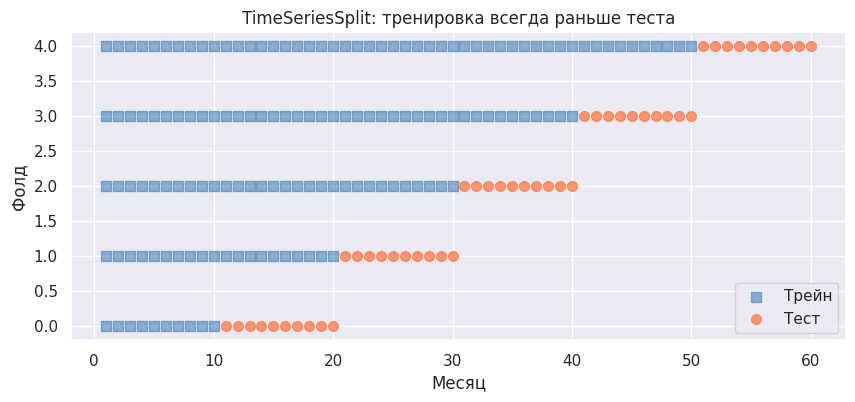

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

plt.figure(figsize=(10, 4))
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_time)):
    # Визуализируем каждое разбиение
    plt.scatter(X_time[train_idx], [fold]*len(train_idx),
                c='steelblue', marker='s', s=50, alpha=0.6, label='Трейн' if fold==0 else '')
    plt.scatter(X_time[test_idx], [fold]*len(test_idx),
                c='coral', marker='o', s=50, alpha=0.8, label='Тест' if fold==0 else '')
    print(f"Фолд {fold+1}: трейн — месяцы 1-{X_time[train_idx[-1]][0]}, тест — {X_time[test_idx[0]][0]}-{X_time[test_idx[-1]][0]}")

plt.xlabel('Месяц')
plt.ylabel('Фолд')
plt.title('TimeSeriesSplit: тренировка всегда раньше теста')
plt.legend()
plt.show()

In [ ]:
# Обучаем модель на каждом временном разбиении
reg = LinearRegression()
ts_mae = []
for train_idx, test_idx in tscv.split(X_time):
    reg.fit(X_time[train_idx], y_time[train_idx])
    pred = reg.predict(X_time[test_idx])
    mae = mean_absolute_error(y_time[test_idx], pred)
    ts_mae.append(mae)
    print(f"MAE: {mae:.0f} руб.")

print(f"\nСредняя MAE по времени: {np.mean(ts_mae):.0f} руб.")

MAE: 1471 руб.
MAE: 372 руб.
MAE: 366 руб.
MAE: 264 руб.
MAE: 365 руб.

Средняя MAE по времени: 568 руб.


## ShuffleSplit — случайные подвыборки

In [ ]:
ss = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
model = LogisticRegression()

ss_accuracies = []
for train_idx, test_idx in ss.split(X_emp):
    model.fit(X_emp[train_idx], y_emp[train_idx])
    acc = accuracy_score(y_emp[test_idx], model.predict(X_emp[test_idx]))
    ss_accuracies.append(acc)

print(f"ShuffleSplit: {len(ss_accuracies)} итераций")
print(f"Средняя accuracy: {np.mean(ss_accuracies):.3f} (±{np.std(ss_accuracies):.3f})")
# В отличие от KFold, здесь каждый образец может попасть в тест несколько раз

ShuffleSplit: 10 итераций
Средняя accuracy: 0.797 (±0.036)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## RepeatedKFold — повторяем KFold

In [ ]:
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
model = LogisticRegression()

rkf_accuracies = []
for train_idx, test_idx in rkf.split(X_emp):
    model.fit(X_emp[train_idx], y_emp[train_idx])
    acc = accuracy_score(y_emp[test_idx], model.predict(X_emp[test_idx]))
    rkf_accuracies.append(acc)

print(f"RepeatedKFold: всего {len(rkf_accuracies)} итераций (5 фолдов × 3 повтора)")
print(f"Средняя accuracy: {np.mean(rkf_accuracies):.3f} (±{np.std(rkf_accuracies):.3f})")
# Больше итераций → более стабильная оценка и честный разброс

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

RepeatedKFold: всего 15 итераций (5 фолдов × 3 повтора)
Средняя accuracy: 0.806 (±0.038)


## LeaveOneOut — каждый образец как тест

In [ ]:
# LeaveOneOut ОЧЕНЬ затратный — для 500 образцов нужно обучить 500 моделей
# Для демонстрации возьмём только первые 30 образцов
X_small = X_emp[:30]
y_small = y_emp[:30]

loo = LeaveOneOut()
loo_accuracies = cross_val_score(LogisticRegression(), X_small, y_small, cv=loo)
print(f"LeaveOneOut на 30 образцах: средняя accuracy = {loo_accuracies.mean():.3f}")
print(f"Число итераций: {len(loo_accuracies)} (равно числу образцов)")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LeaveOneOut на 30 образцах: средняя accuracy = 0.833
Число итераций: 30 (равно числу образцов)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Для данных об оттоке сотрудников сравните accuracy при test_size = 0.1, 0.2, 0.3. Как меняется точность?
2. Создайте искусственный датасет с сильным дисбалансом классов (5% ушедших). Сравните KFold и StratifiedKFold.
3. Для временного ряда попробуйте разные значения gap (0, 2, 5) в TimeSeriesSplit. Как это влияет на MAE?
4. Сгенерируйте данные с группами (по 3-5 записей на клиента) и проверьте, что GroupKFold действительно не допускает пересечений.

In [ ]:
# твой код